In [1]:
%pip install gdown

In [2]:
%pip install --upgrade ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.2/624.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.11.0 which is incompatible.
moviep

In [3]:
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

In [4]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


# Импорты

In [5]:
from model.dataset import TorchDataset
from model.settings import IMAGES_DIR, ROOM_TYPES, VALID_ROOM_TYPES, CLASS_NAME_MAPPING
from model.classifier import RoomModel
from model.trainer import TrainerUtils, predict_img_batch
from model.utils import (
    get_preprocessor,
    plot_imgs_with_labels,
    plot_sample,
    load_images,
    load_or_download_df,
)
from model.metrics import Metrics

from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch import nn
import torch
from tqdm import tqdm_notebook

import gdown
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from transformers import get_linear_schedule_with_warmup

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import logging
import re


logger = logging.getLogger()
logger.setLevel(logging.INFO)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


# Вспомогательные функции

In [7]:
def score_model(model_name, test_dataloader, trainer_obj, scorer, base_model_path):
    model_path = os.path.join(base_model_path, f"model_{model_name}")
    loaded_model, meta_info = RoomModel.from_pretrained(model_path)
    loaded_model = loaded_model.to(device)

    test_predictions, test_probas, test_targets, _ = trainer_obj.predict(
        loaded_model, test_dataloader, with_all_probas=False
    )

    scores_df = scorer.get_accuracies_df(test_targets, test_predictions)
    return scores_df, test_targets, test_predictions

# Скачать данные

In [10]:
DRIVE_BASE_DIR = "/content/drive/MyDrive/AAA/Datasets_course"
DRIVE_WORKING_DATA = os.path.join(DRIVE_BASE_DIR, "working_data")

MODELS_DIR = os.path.join(DRIVE_WORKING_DATA, "models")
SUBMITS_DIR = os.path.join(DRIVE_WORKING_DATA, "submissions")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(SUBMITS_DIR, exist_ok=True)

# 2. Настройка локальных путей Colab
LOCAL_BASE_DIR = "/content/local_data"
LOCAL_IMAGES_DIR = os.path.join(LOCAL_BASE_DIR, "images")
LOCAL_CSV_DIR = os.path.join(LOCAL_BASE_DIR, "csv")

os.makedirs(LOCAL_IMAGES_DIR, exist_ok=True)
os.makedirs(LOCAL_CSV_DIR, exist_ok=True)

In [14]:
IMAGE_FILE_IDS = {
    # "train_images.zip": "1IQ_atzZL6YabDGVGN6mmznnkJFKnRm-D",
    "val_images.zip": "16_ekO1u6l9xRD8tVE2Bt_r7au0hJH73m",
    # "heuristics_images.zip": "1QrunclZtBrRWkd4fyFrAccd-PPU2LZbJ",
}

CSV_FILE_IDS = {
    "train_df.csv": "1ERYXdlIrpuhBbjokbvs5miQB4Ukyids5",
    "val_df.csv": "1C0j3j78HwU_aJBBfraDF8aplQBGxndIY",
    "test_df.csv": "1eToNc2BiZymhempG4GW29do8VsY0aVbd",
    "heuristics_dressing_room.csv": "1Zyw14BTtTBdyCH221hTBw0f3D5QBYjPl",
    "heuristics_cabinet.csv": "1yT50FS2uSeMApyomYJGxYQ-MABz_BrRx",
    "heuristics_detskaya.csv": "1CJalvaugWLWt_Tdku2s9hmoAv19LAqTJ",
}

In [15]:
def download_and_extract(file_name, file_id, extract_to_base):
    folder_name = file_name.replace(".zip", "")
    target_dir = os.path.join(extract_to_base, folder_name)

    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"Директория {folder_name} уже существует. Пропуск.")
        return

    print(f"Скачивание архива: {file_name}")
    zip_path = os.path.join(LOCAL_BASE_DIR, file_name)
    gdown.download(id=file_id, output=zip_path, quiet=True)

    print(f"Распаковка архива: {file_name}")
    os.system(f"unzip -q {zip_path} -d {extract_to_base}")

    os.remove(zip_path)


def fix_image_paths(df, folder_name):
    df_copy = df.copy()

    def make_path(img_id):
        filename = str(img_id)
        if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
            filename += ".jpg"
        return os.path.join(LOCAL_IMAGES_DIR, folder_name, filename)

    df_copy["img_path"] = df_copy["image_id_ext"].apply(make_path)
    return df_copy


print("--- Старт обработки изображений ---")
for file_name, file_id in IMAGE_FILE_IDS.items():
    download_and_extract(file_name, file_id, LOCAL_IMAGES_DIR)

print("--- Старт загрузки разметки ---")
for file_name, file_id in CSV_FILE_IDS.items():
    csv_path = os.path.join(LOCAL_CSV_DIR, file_name)
    if not os.path.exists(csv_path):
        print(f"Скачивание файла: {file_name}")
        gdown.download(id=file_id, output=csv_path, quiet=True)

print("--- Обновление локальных путей в DataFrame ---")
train_df = pd.read_csv(os.path.join(LOCAL_CSV_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(LOCAL_CSV_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(LOCAL_CSV_DIR, "test_df.csv"))

train_df = fix_image_paths(train_df, "train_images")
val_df = fix_image_paths(val_df, "val_images")
test_df = fix_image_paths(test_df, "test_images")

dress_room_df = pd.read_csv(os.path.join(LOCAL_CSV_DIR, "heuristics_dressing_room.csv"))
cabinet_df = pd.read_csv(os.path.join(LOCAL_CSV_DIR, "heuristics_cabinet.csv"))
detskaya_df = pd.read_csv(os.path.join(LOCAL_CSV_DIR, "heuristics_detskaya.csv"))

dress_room_df = fix_image_paths(dress_room_df, "heuristics_images")
cabinet_df = fix_image_paths(cabinet_df, "heuristics_images")
detskaya_df = fix_image_paths(detskaya_df, "heuristics_images")

print("Инициализация успешно завершена.")
print(f"Пример пути (train): {train_df['img_path'].iloc[0]}")

--- Старт обработки изображений ---
Скачивание архива: val_images.zip
Распаковка архива: val_images.zip
--- Старт загрузки разметки ---
Скачивание файла: train_df.csv
Скачивание файла: val_df.csv
Скачивание файла: test_df.csv
Скачивание файла: heuristics_dressing_room.csv
Скачивание файла: heuristics_cabinet.csv
Скачивание файла: heuristics_detskaya.csv
--- Обновление локальных путей в DataFrame ---
Инициализация успешно завершена.
Пример пути (train): /content/local_data/images/train_images/16028356846.jpg


## Небольшой анализ данных

In [24]:
train_df.columns

Index(['item_id', 'image', 'image_id_ext', 'result', 'label', 'ratio',
       'img_path'],
      dtype='object')

In [25]:
train_df.shape

(4562, 7)

In [ ]:
train_df["label"].value_counts()

,count
label,
другое,270
туалет,255
ванная комната,255
совмещенный санузел,254
комната без мебели,253
подъезд / лестничная площадка,253
спальня,251
не могу дать ответ / не ясно,251
предметы интерьера / быт.техника,250


In [ ]:
columns = [
    TorchDataset.img_path_column,
    TorchDataset.label_column,
    TorchDataset.image_id_column,
    "label",
    "ratio",
]

In [28]:
train_df[columns].head(3)

,img_path,result,image_id_ext,label,ratio
0,/content/local_data/images/train_images/160283...,9,16028356846,совмещенный санузел,1.000000
1,/content/local_data/images/train_images/160297...,1,16029739656,кухня-гостиная,0.666667
2,/content/local_data/images/train_images/152091...,10,15209120394,коридор / прихожая,1.000000


In [29]:
val_df[columns].head(3)

,img_path,result,image_id_ext,label,ratio
0,/content/local_data/images/val_images/14443810...,12,14443810553,балкон / лоджия,1.000000
1,/content/local_data/images/val_images/14488540...,6,14488540893,детская,0.666667
2,/content/local_data/images/val_images/14472154...,3,14472154239,гостиная,1.000000


In [ ]:
train_df["ratio"].value_counts()

,count
ratio,
1.000000,2859
0.666667,1695
0.600000,6
0.800000,2


## Датасет и даталоадер

In [ ]:
dataset_train = TorchDataset(
    image_dir=LOCAL_IMAGES_DIR, df=train_df, transformer=get_preprocessor()
)
dataset_val = TorchDataset(
    image_dir=LOCAL_IMAGES_DIR, df=val_df, transformer=get_preprocessor()
)

train_dataloader = DataLoader(
    dataset_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)
val_dataloader = DataLoader(
    dataset_val, batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

print(f"Количество батчей (Train): {len(train_dataloader)}")
print(f"Количество батчей (Val): {len(val_dataloader)}")

Количество батчей (Train): 143
Количество батчей (Val): 16


# Анализ детских

In [42]:
detskaya_df

,image_id_ext,item_id_ext,microcat_name,title,description,price,crop_coords,crop_area,is_catalog,n_texts,person_found,perform_top_microcat_value,perform_top_microcat_name,perform_top_microcat_prob,perform_top_other_classes_value,perform_top_other_classes_prob,image,img_path
0,15986849237,2669964578,Спальные гарнитуры,Спальня Мартина,Спальня Мартина\n \nВажное отличие - мебель вс...,18700.0,"[0.2204589694738388, 0.1370442658662796, 0.957...",0.575589,False,3,False,237,"Кровати, диваны и кресла",0.246469,Скриншоты переписок,0.031009,http://labelimages.avito.ru/15986849237.jpg,/content/local_data/images/heuristics_images/1...
1,15979254876,2660519156,Спальные гарнитуры,Спальная мебель бу,Спальная мебель б/у,20000.0,"[0.191650390625, 0.2275390625, 0.951171875, 0....",0.543186,False,1,False,237,"Кровати, диваны и кресла",0.765472,Комната,0.845141,http://labelimages.avito.ru/15979254876.jpg,/content/local_data/images/heuristics_images/1...
2,16001041449,2708558104,Спальные гарнитуры,Спальный гарнитур с матрасом Саманта,Спальный гарнитур с матрасом Саманта\n \nБЕСПЛ...,67990.0,"[0.066162109375, 0.07451396435499191, 0.794433...",0.614579,False,0,False,237,"Кровати, диваны и кресла",0.836585,Скриншоты переписок,0.010549,http://labelimages.avito.ru/16001041449.jpg,/content/local_data/images/heuristics_images/1...
3,15941608501,2654877091,Кровати,Кровать Фиеста NEW 0.9 м венге / лоредо,Кровать с мягким изголовьем новая в наличии. В...,4536.0,"[0.06585693359375, 0.15848475694656372, 0.9379...",0.659147,True,2,False,237,"Кровати, диваны и кресла",0.907106,Алкоголь,0.010479,http://labelimages.avito.ru/15941608501.jpg,/content/local_data/images/heuristics_images/1...
4,15955640067,2700693976,Спальные гарнитуры,Спальный гарнитур Ампир с матрасом в комплекте,Спальный гарнитур Ампир с матрасом в комплекте...,61650.0,"[0.0185546875, 0.08669354766607285, 0.97412109...",0.789081,False,1,False,237,"Кровати, диваны и кресла",0.506734,Планировка квартиры,0.018787,http://labelimages.avito.ru/15955640067.jpg,/content/local_data/images/heuristics_images/1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14734,16052280771,2659190976,Кровати,Детская кроватка трансформер с маятником круглая,"Манеж-кровать в хорошем состоянии, есть незнач...",5500.0,"[0.1239013671875, 0.0798611119389534, 0.835937...",0.614378,False,4,False,275,Игрушки,0.408749,Дети,0.058393,http://labelimages.avito.ru/16052280771.jpg,/content/local_data/images/heuristics_images/1...
14735,15798071108,2653172417,Кровати,Детская кровать,Это Фабрика хорошего настроения!🙂 Мы находимся...,55000.0,"[0.217041015625, 0.10143089294433594, 0.821777...",0.466673,NaN,1,NaN,275,Игрушки,0.565875,Скриншоты переписок,0.005426,http://labelimages.avito.ru/15798071108.jpg,/content/local_data/images/heuristics_images/1...
14736,16051509906,2706119542,Кровати,Изголовье для кровати,Изголовье под заказ. Любого цвета и размера. П...,10000.0,"[0.0222981758415699, 0.2158203125, 0.966796875...",0.610142,False,1,False,5536,Салон,0.242166,Планировка,0.392039,http://labelimages.avito.ru/16051509906.jpg,/content/local_data/images/heuristics_images/1...
14737,16053061703,2682390219,Кровати,Кровать односпальная,Односпальная кровать с двумя выдвижными ящиками,4500.0,"[0.1490478515625, 0.3522135317325592, 0.863769...",0.344332,False,1,False,539,Меконгский бобтейл,0.236940,Дети,0.034452,http://labelimages.avito.ru/16053061703.jpg,/content/local_data/images/heuristics_images/1...


In [ ]:
print(f"Исходная размерность 'Детская': {detskaya_df.shape}\n")

print("--- Топ-15 микрокатегорий ---")
print(detskaya_df["perform_top_microcat_name"].value_counts().head(15), "\n")

print("--- Флаги ML-моделей ---")
print("Каталожные (is_catalog):")
print(detskaya_df["is_catalog"].value_counts(), "\n")

print("Люди в кадре (person_found):")
print(detskaya_df["person_found"].value_counts(), "\n")

Исходная размерность 'Детская': (14739, 18)

--- Топ-15 микрокатегорий ---
perform_top_microcat_name
Кровати, диваны и кресла    13605
Окна и балконы                858
Путешествия                    53
Для ресторана                  32
Другое                         30
Для магазина                   26
Багажники и фаркопы            13
Бумага                         11
Двери                          10
Туризм                          7
Прицепы                         5
Автодома                        5
Промышленное                    5
Вытяжки                         5
Медицинские изделия             4
Name: count, dtype: int64 

--- Флаги ML-моделей ---
Каталожные (is_catalog):
is_catalog
False    14215
True       522
Name: count, dtype: int64 

Люди в кадре (person_found):
person_found
False    14730
True         7
Name: count, dtype: int64 



In [ ]:
include_detskaya = [
    re.compile(r"детск"),
    re.compile(r"игров"),
    re.compile(r"ребенк"),
    re.compile(r"подростк"),
]

exclude_detskaya = [
    re.compile(r"коляск"),
    re.compile(r"спальный гарни"),
    re.compile(r"двуспаль"),
    re.compile(r"игрушк"),
    re.compile(r"одежд"),
    re.compile(r"вещ"),
    re.compile(r"взросл"),
]


def check_detskaya(text):
    if not isinstance(text, str):
        return 0
    text = text.lower()
    if any(ex_r.search(text) for ex_r in exclude_detskaya):
        return 0
    if any(inc_r.search(text) for inc_r in include_detskaya):
        return 1
    return 0


detskaya_df["match"] = detskaya_df["title"].apply(check_detskaya) | detskaya_df[
    "description"
].apply(check_detskaya)

clean_detskaya = detskaya_df[
    (detskaya_df["match"] == 1)
    & (detskaya_df["is_catalog"] == False)
    & (detskaya_df["person_found"] == False)
    & (detskaya_df.get("n_texts", 0) < 3)
    & (detskaya_df["perform_top_microcat_name"] == "Кровати, диваны и кресла")
    & (~detskaya_df["microcat_name"].str.lower().str.contains("спальн", na=False))
].copy()

print(f"Размерность после удаления спален: {clean_detskaya.shape[0]}")

Размерность после удаления спален: 152


Берем в итоговый датасет: 152 изображений

Примеры отобранных фотографий детских комнат:


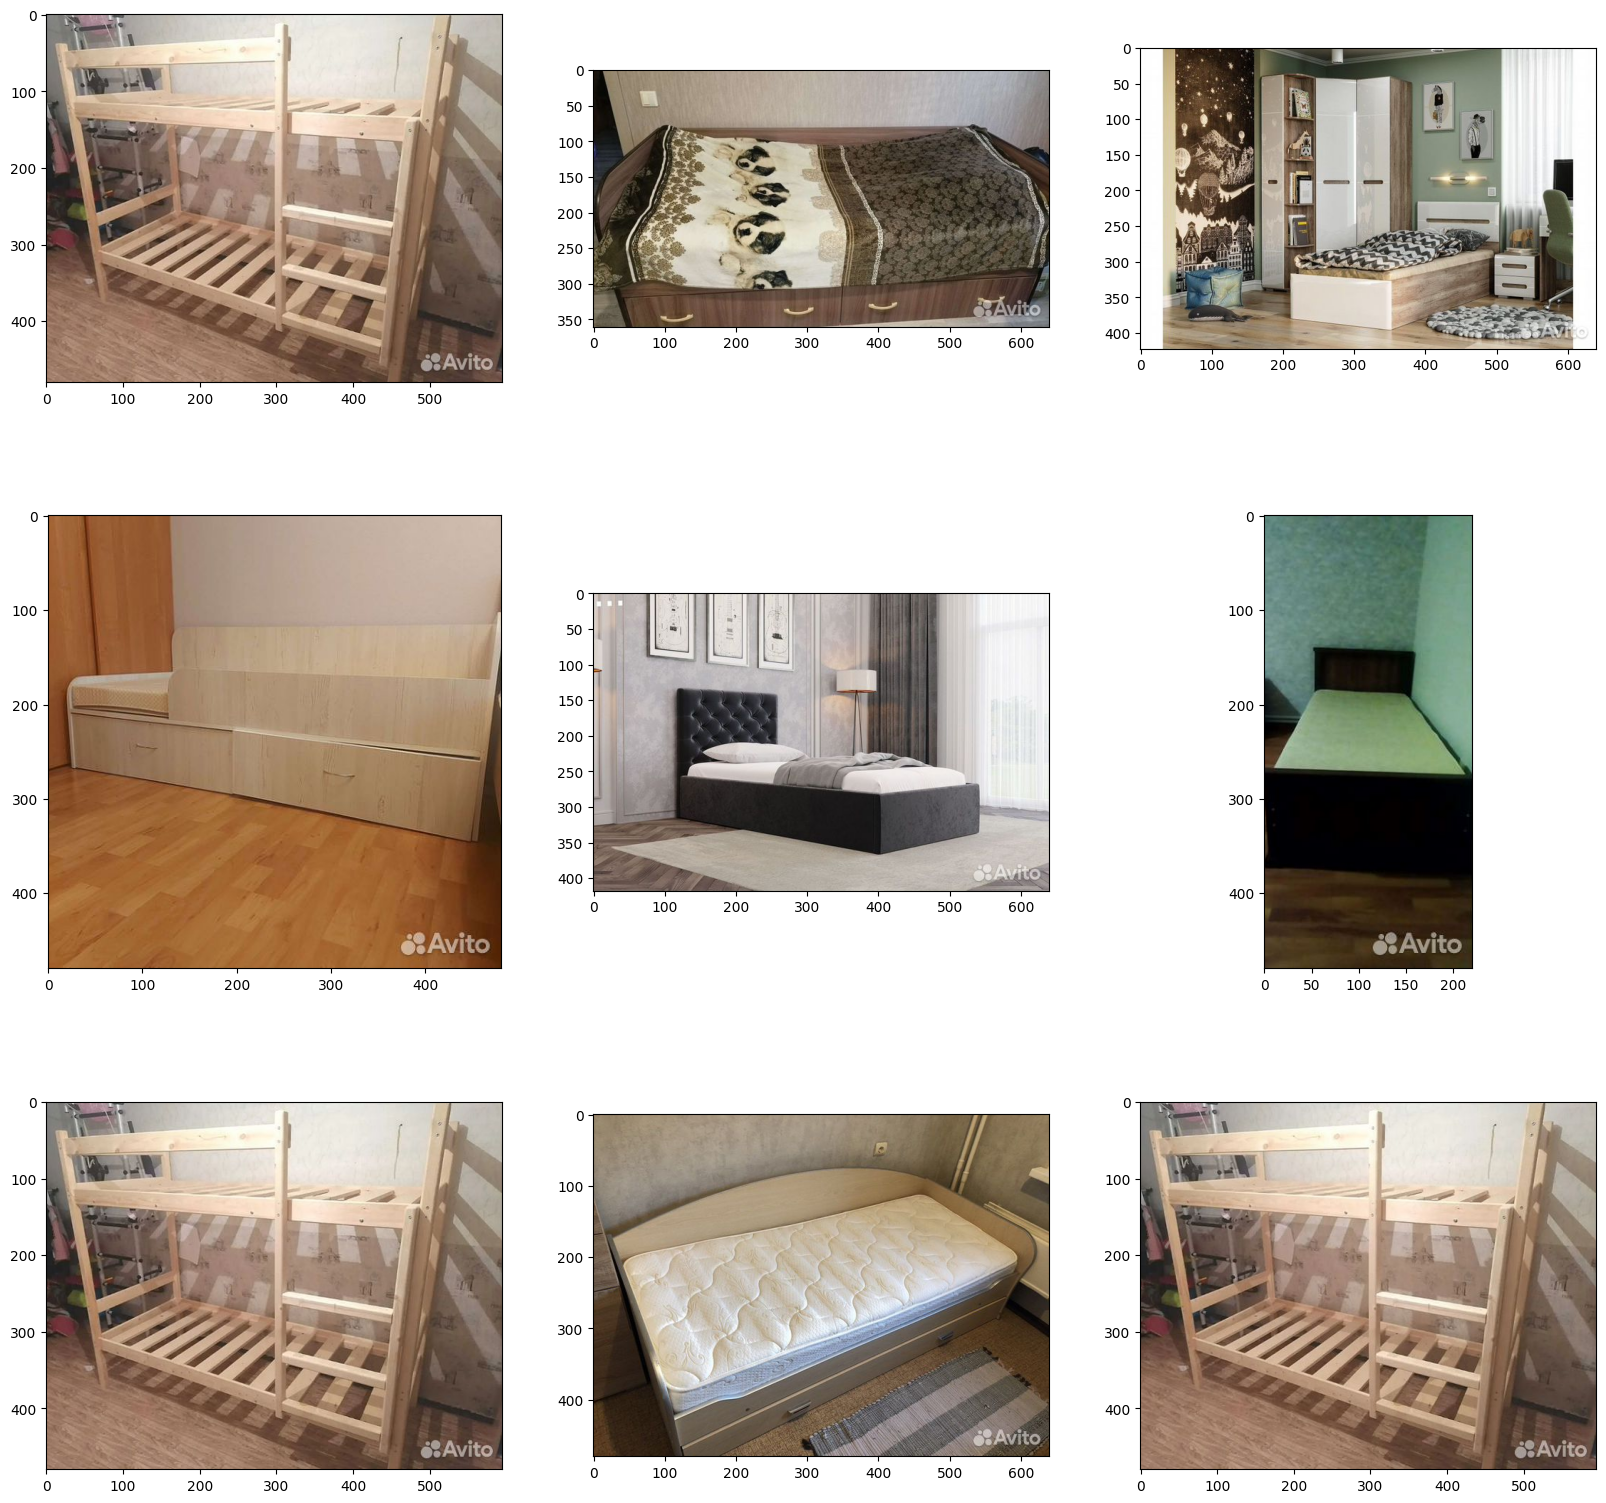

In [ ]:
sample_size = 200
if clean_detskaya.shape[0] > sample_size:
    final_detskaya_df = clean_detskaya.sample(
        n=sample_size, random_state=42
    ).reset_index(drop=True)
else:
    final_detskaya_df = clean_detskaya.reset_index(drop=True)

print(f"Берем в итоговый датасет: {final_detskaya_df.shape[0]} изображений")

if final_detskaya_df.shape[0] >= 9:
    print("\nПримеры отобранных фотографий детских комнат:")
    plot_imgs_with_labels(
        final_detskaya_df.sample(9, random_state=15)["img_path"].reset_index(drop=True)
    )

# Анализ кабинетов

In [ ]:
include_cabinet = [
    re.compile(r"кабинет"),
    re.compile(r"рабоч\w*\sмест"),
    re.compile(r"компьютерн\w*\sстол"),
    re.compile(r"письменн\w*\sстол"),
    re.compile(r"домашн\w*\sофис"),
]

exclude_cabinet = [
    re.compile(r"кухн"),
    re.compile(r"спальн"),
    re.compile(r"детск"),
    re.compile(r"маникюр"),
    re.compile(r"педикюр"),
    re.compile(r"массаж"),
    re.compile(r"бров"),
    re.compile(r"ресниц"),
    re.compile(r"салон"),
    re.compile(r"аренд\w*\sкресл"),  # аренда кресла парикмахера и т.д.
]


def check_cabinet(text):
    if not isinstance(text, str):
        return 0
    text = text.lower()
    if any(ex_r.search(text) for ex_r in exclude_cabinet):
        return 0
    if any(inc_r.search(text) for inc_r in include_cabinet):
        return 1
    return 0

In [ ]:
cabinet_df["match"] = cabinet_df["title"].apply(check_cabinet) | cabinet_df[
    "description"
].apply(check_cabinet)

clean_cabinet = cabinet_df[
    (cabinet_df["match"] == 1)
    & (cabinet_df["is_catalog"] == False)
    & (cabinet_df["person_found"] == False)
    & (cabinet_df.get("n_texts", 0) < 2)
].copy()

print(f"Размерность после жесткой фильтрации: {clean_cabinet.shape[0]}")

Размерность после жесткой фильтрации: 5614


In [ ]:
print(clean_cabinet["perform_top_microcat_name"].value_counts().head(10))

perform_top_microcat_name
Компьютерные столы и кресла    4232
Столы и стулья                  428
Ресепшены и офисная мебель      338
Для салона красоты              237
Подставки и тумбы                94
Кухонные гарнитуры               47
Шкафы, комоды и стеллажи         33
Другое                           32
Детская мебель                   23
Настольные компьютеры            22
Name: count, dtype: int64


In [ ]:
# Список категорий для визуального анализа
categories_to_check = [
    "Компьютерные столы и кресла",
    "Столы и стулья",
    "Ресепшены и офисная мебель",
    "Подставки и тумбы",
]

for cat in categories_to_check:
    print(f"\n{'=' * 50}")
    print(f"Микрокатегория: {cat}")
    print(f"{'=' * 50}")

    sample_df = clean_cabinet[clean_cabinet["perform_top_microcat_name"] == cat]

    sample_paths = sample_df.sample(5, random_state=42)["img_path"].tolist()
    plot_imgs_with_labels(sample_paths)

# Обучаем модели

## Бейзлайн

In [ ]:
room_clf = RoomModel(num_classes=len(ROOM_TYPES))
room_clf = room_clf.to(device)

optimizer = AdamW(room_clf.parameters(), lr=0.0002)
metrics_scorer = Metrics(class_mapping=CLASS_NAME_MAPPING)

trainer = TrainerUtils(
    device=device, experiment_tag="resnet18_baseline", model_checkpoint_path=MODELS_DIR
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


In [ ]:
trainer.training_loop(
    room_clf,
    train_dataloader,
    val_dataloader,
    optimizer,
    epoch_num=20,
    validate_every=10,
    verbose=True,
    metrics_scorer=metrics_scorer,
)

In [ ]:
scores_df_base, val_targets, val_predictions = score_model(
    "resnet18_baseline",
    val_dataloader,
    trainer,
    metrics_scorer,
    base_model_path=MODELS_DIR,
)
print(scores_df_base)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  0%|          | 0/16 [00:00<?, ?it/s]

                                   index  precision    recall  f1-score  \
19                             micro avg   0.707819  0.688000  0.697769   
21                          weighted avg   0.721308  0.688000  0.677658   
20                             macro avg   0.719420  0.677311  0.669360   
6                                детская   0.583333  0.411765  0.482759   
0                       кухня / столовая   0.743590  0.852941  0.794521   
15         подъезд / лестничная площадка   1.000000  0.878788  0.935484   
8                                 туалет   0.931034  0.818182  0.870968   
9                    совмещенный санузел   0.794118  0.870968  0.830769   
3                               гостиная   0.657143  0.766667  0.707692   
10                    коридор / прихожая   0.696970  0.793103  0.741935   
16                                другое   0.380952  0.857143  0.527473   
17      предметы интерьера / быт.техника   0.571429  0.296296  0.390244   
11  гардеробная / кладова

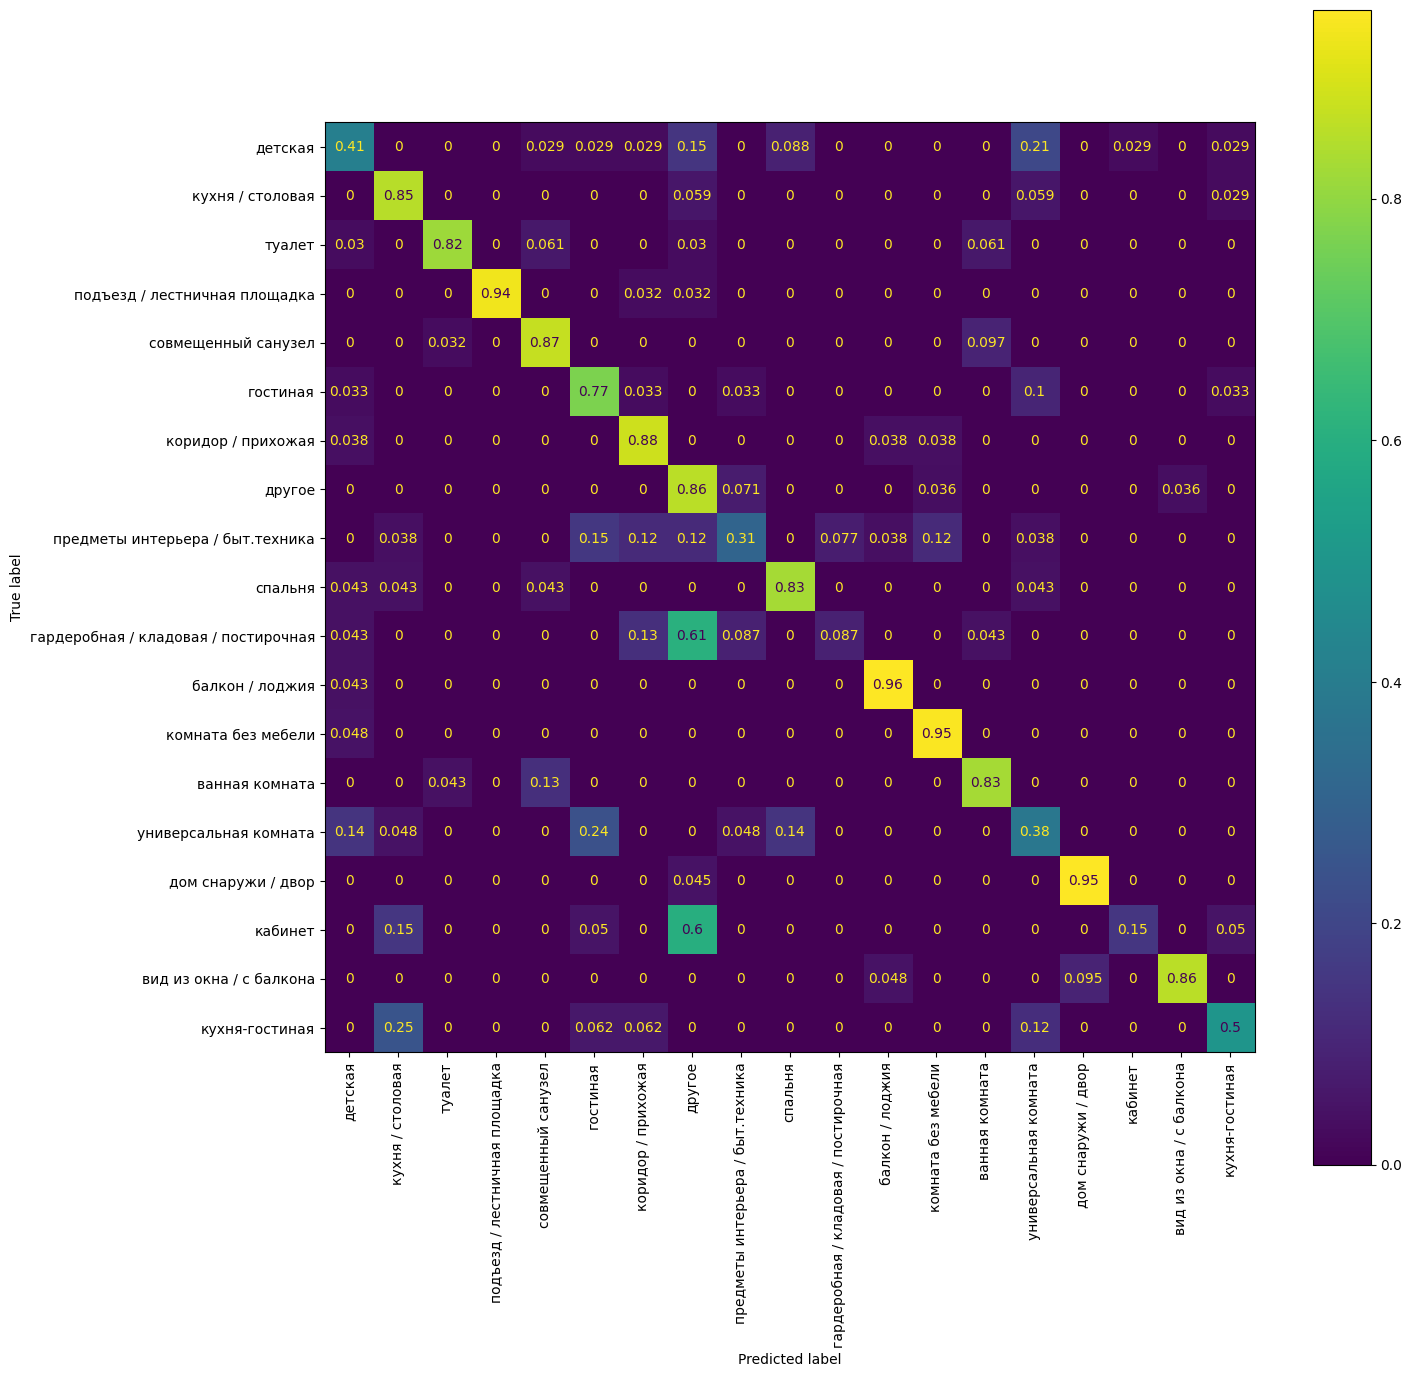

In [22]:
metrics_scorer.plot_cf_matrix(val_targets, val_predictions)

##  Добавим веса в лосс

    loss_fn = torch.nn.CrossEntropyLoss(reduction='none')
    loss_batch = loss_fn(logits, labels)
    loss_batch = loss_batch * sample_weights

    loss = loss_batch.mean()

## Добавим эвристик для гардробных



In [32]:
import re

In [ ]:
include_re = [
    re.compile(r"гардеробн"),
    re.compile(r"кладов"),
    re.compile(r"постирочн"),
    re.compile(r"прачечн"),
    re.compile(r"система хранения"),
]

exclude_re = [
    re.compile(r"шкаф"),
    re.compile(r"купе"),
    re.compile(r"прихож"),
    re.compile(r"спальн"),
    re.compile(r"вешалк"),
    re.compile(r"кронштейн"),
    re.compile(r"на заказ"),
]


def check_regex(text):
    if not isinstance(text, str):
        return 0
    text = text.lower()
    if any(ex_r.search(text) for ex_r in exclude_re):
        return 0
    if any(inc_r.search(text) for inc_r in include_re):
        return 1
    return 0


dress_room_df["title_match"] = dress_room_df["title"].apply(check_regex)
dress_room_df["description_match"] = dress_room_df["description"].apply(check_regex)

strict_match_condition = (dress_room_df["title_match"] == 1) & (
    dress_room_df["description_match"] == 1
)

print(
    f"Размерность после строгой фильтрации (title AND description): {dress_room_df[strict_match_condition].shape[0]}"
)

Размерность после строгой фильтрации (title AND description): 296


In [35]:
filtered_df = dress_room_df[
    strict_match_condition
    & (dress_room_df["is_catalog"] == False)
    & (dress_room_df["person_found"] == False)
    & (dress_room_df["n_texts"] < 3)
].reset_index(drop=True)

print(f"Итоговая размерность после отсева шума: {filtered_df.shape[0]}")

Итоговая размерность после отсева шума: 175


In [ ]:
final_dress_room_df = filtered_df.copy()

final_dress_room_df["label"] = "гардеробная / кладовая / постирочная"
final_dress_room_df["result"] = 11
final_dress_room_df["ratio"] = 1.0
final_dress_room_df["sample_weight"] = 1.0

if "sample_weight" not in train_df.columns:
    train_df["sample_weight"] = 1.0

columns_to_keep = [
    "img_path",
    "image_id_ext",
    "label",
    "result",
    "ratio",
    "sample_weight",
]

train_df_heur = pd.concat(
    [train_df[columns_to_keep], final_dress_room_df[columns_to_keep]], ignore_index=True
)

print(f"Размер исходного train: {train_df.shape[0]}")
print(f"Размер train с добавленными гардеробными: {train_df_heur.shape[0]}")

# 2. Создание Dataset и DataLoader
dataset_train_heur = TorchDataset(
    image_dir=LOCAL_IMAGES_DIR, df=train_df_heur, transformer=get_preprocessor()
)

train_dataloader_heur = DataLoader(
    dataset_train_heur, batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)

Размер исходного train: 4562
Размер train с добавленными гардеробными: 4737


In [ ]:
room_clf_heur = RoomModel(num_classes=len(ROOM_TYPES)).to(device)
optimizer_heur = AdamW(room_clf_heur.parameters(), lr=0.0002)

trainer_heur = TrainerUtils(
    device=device,
    experiment_tag="resnet18_heur_dress_room",
    model_checkpoint_path=MODELS_DIR,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [38]:
trainer_heur.training_loop(
    room_clf_heur,
    train_dataloader_heur,
    val_dataloader,  # Используем тот же валидационный лоадер
    optimizer_heur,
    epoch_num=10,
    validate_every=5,  # Валидация на 5 и 10 эпохе
    verbose=True,
    metrics_scorer=metrics_scorer,
)

  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

INFO:root:val accuracy after epoch 0: 0.638
INFO:root:val f1_score after epoch 0: 0.6271


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

INFO:root:val accuracy after epoch 8: 0.662
INFO:root:val f1_score after epoch 8: 0.6505


  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

INFO:root:val accuracy after epoch 9: 0.67
INFO:root:val f1_score after epoch 9: 0.6589


In [ ]:
scores_df_heur, val_targets_heur, val_preds_heur = score_model(
    "resnet18_heur_dress_room",
    val_dataloader,
    trainer_heur,
    metrics_scorer,
    base_model_path=MODELS_DIR,
)
scores_df_heur

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  0%|          | 0/16 [00:00<?, ?it/s]

,index,precision,recall,f1-score,support
19,micro avg,0.706612,0.684000,0.695122,500.0
21,weighted avg,0.711565,0.684000,0.686289,500.0
20,macro avg,0.702579,0.681923,0.680471,500.0
6,детская,0.600000,0.441176,0.508475,34.0
0,кухня / столовая,0.900000,0.529412,0.666667,34.0
15,подъезд / лестничная площадка,0.875000,0.848485,0.861538,33.0
8,туалет,0.875000,0.848485,0.861538,33.0
9,совмещенный санузел,0.741935,0.741935,0.741935,31.0
3,гостиная,0.620690,0.600000,0.610169,30.0
10,коридор / прихожая,0.689655,0.689655,0.689655,29.0


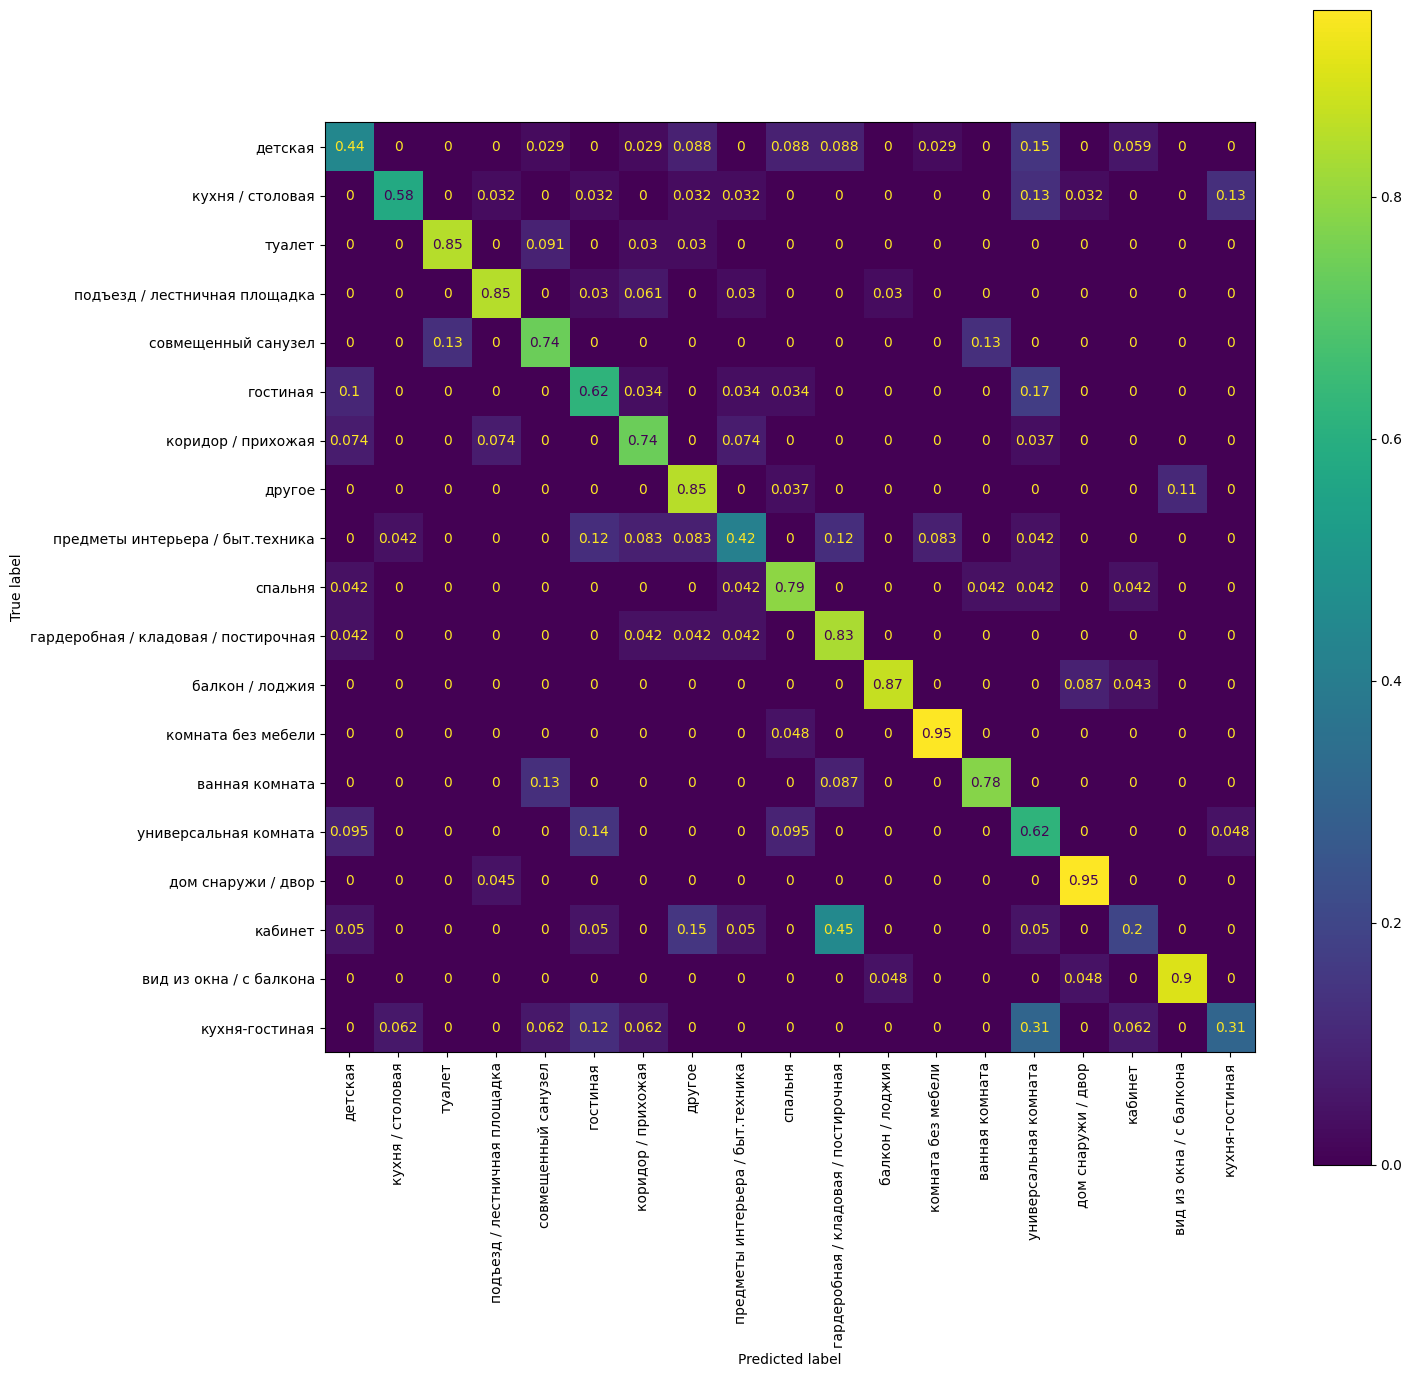

In [40]:
metrics_scorer.plot_cf_matrix(val_targets_heur, val_preds_heur)

In [41]:
print("--- Статистика видеопамяти ДО очистки ---")
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv

# Статистика самого PyTorch
allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3
print(f"PyTorch использует под тензоры: {allocated:.2f} GB")
print(f"PyTorch зарезервировал (держит в кэше): {reserved:.2f} GB")

--- Статистика видеопамяти ДО очистки ---
memory.used [MiB], memory.total [MiB]
1351 MiB, 15360 MiB
PyTorch использует под тензоры: 0.23 GB
PyTorch зарезервировал (держит в кэше): 1.18 GB


## Остальные эвристики

In [ ]:
print("--- 1. Подготовка эвристик для ГАРДЕРОБНОЙ ---")
strict_match_condition = (dress_room_df["title_match"] == 1) & (
    dress_room_df["description_match"] == 1
)
bad_microcats_dress = [
    "Детская мебель",
    "Кухонные гарнитуры",
    "Фитнес и тренажёры",
    "Товары для животных",
    "Багажники и фаркопы",
]

final_dress = dress_room_df[
    strict_match_condition
    & (dress_room_df["is_catalog"] == False)
    & (dress_room_df["person_found"] == False)
    & (dress_room_df.get("n_texts", 0) < 3)
    & (~dress_room_df["perform_top_microcat_name"].isin(bad_microcats_dress))
].copy()

final_dress["label"] = "гардеробная / кладовая / постирочная"
final_dress["result"] = 11

print("--- 2. Подготовка эвристик для ДЕТСКОЙ ---")
clean_detskaya = detskaya_df[
    (detskaya_df["match"] == 1)
    & (detskaya_df["is_catalog"] == False)
    & (detskaya_df["person_found"] == False)
    & (detskaya_df.get("n_texts", 0) < 3)
    & (detskaya_df["perform_top_microcat_name"] == "Кровати, диваны и кресла")
    & (~detskaya_df["microcat_name"].str.lower().str.contains("спальн", na=False))
].copy()

# Исправлено: проверяем размер перед сэмплированием
if clean_detskaya.shape[0] > 200:
    final_detskaya = clean_detskaya.sample(n=200, random_state=42).reset_index(
        drop=True
    )
else:
    final_detskaya = clean_detskaya.reset_index(drop=True)

final_detskaya["label"] = "детская"
final_detskaya["result"] = 6

print("--- 3. Подготовка эвристик для КАБИНЕТА ---")
approved_cab_cats = [
    "Компьютерные столы и кресла",
    "Столы и стулья",
    "Ресепшены и офисная мебель",
    "Подставки и тумбы",
]

clean_cabinet = cabinet_df[
    (cabinet_df["match"] == 1)
    & (cabinet_df["is_catalog"] == False)
    & (cabinet_df["person_found"] == False)
    & (cabinet_df.get("n_texts", 0) < 3)
    & (cabinet_df["perform_top_microcat_name"].isin(approved_cab_cats))
].copy()

# Исправлено: проверяем размер перед сэмплированием
if clean_cabinet.shape[0] > 180:
    final_cabinet = clean_cabinet.sample(n=180, random_state=42).reset_index(drop=True)
else:
    final_cabinet = clean_cabinet.reset_index(drop=True)

final_cabinet["label"] = "кабинет"
final_cabinet["result"] = 5


print("--- 4. Формирование Итогового Датасета ---")
for df_ in [final_dress, final_detskaya, final_cabinet]:
    df_["ratio"] = 1.0
    df_["sample_weight"] = 1.0

if "sample_weight" not in train_df.columns:
    train_df["sample_weight"] = 1.0

columns_to_keep = [
    "img_path",
    "image_id_ext",
    "label",
    "result",
    "ratio",
    "sample_weight",
]

train_df_ultimate = pd.concat(
    [
        train_df[columns_to_keep],
        final_dress[columns_to_keep],
        final_detskaya[columns_to_keep],
        final_cabinet[columns_to_keep],
    ],
    ignore_index=True,
)

print(f"Размер исходного train: {train_df.shape[0]}")
print(
    f"Добавлено чистых фото: {final_dress.shape[0] + final_detskaya.shape[0] + final_cabinet.shape[0]}"
)
print(f"Размер итогового train_ultimate: {train_df_ultimate.shape[0]}")

--- 1. Подготовка эвристик для ГАРДЕРОБНОЙ ---
--- 2. Подготовка эвристик для ДЕТСКОЙ ---
--- 3. Подготовка эвристик для КАБИНЕТА ---
--- 4. Формирование Итогового Датасета ---
Размер исходного train: 4562
Добавлено чистых фото: 494
Размер итогового train_ultimate: 5056


In [72]:
dataset_train_ult = TorchDataset(
    image_dir=LOCAL_IMAGES_DIR, df=train_df_ultimate, transformer=get_preprocessor()
)
train_dataloader_ult = DataLoader(
    dataset_train_ult, batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)

device = "cuda" if torch.cuda.is_available() else "cpu"
room_clf_ult = RoomModel(num_classes=len(ROOM_TYPES)).to(device)
optimizer_ult = AdamW(room_clf_ult.parameters(), lr=0.0002)

trainer_ult = TrainerUtils(
    device=device,
    experiment_tag="resnet18_ultimate_heuristics",
    model_checkpoint_path=MODELS_DIR,
)

trainer_ult.training_loop(
    room_clf_ult,
    train_dataloader_ult,
    val_dataloader,
    optimizer_ult,
    epoch_num=15,
    validate_every=5,
    verbose=True,
    metrics_scorer=metrics_scorer,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  0%|          | 0/158 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

INFO:root:val accuracy after epoch 0: 0.63
INFO:root:val f1_score after epoch 0: 0.606


  0%|          | 0/158 [00:00<?, ?it/s]

...

INFO:root:val accuracy after epoch 8: 0.716
INFO:root:val f1_score after epoch 8: 0.7031


  0%|          | 0/158 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

: 

: 

In [ ]:
scores_df_ult, val_targets_ult, val_preds_ult = score_model(
    "resnet18_ultimate_heuristics",
    val_dataloader,
    trainer_ult,
    metrics_scorer,
    base_model_path=MODELS_DIR,
)
scores_df_ult

# Сабмишн

In [8]:
from model.trainer import predict_img_batch

In [12]:
TEST_ZIP_ID = '1qb-Eo0iU4u32Z9K6H_hwkdmJOcpwrROO' 
test_target_dir = os.path.join(LOCAL_IMAGES_DIR, 'test_images')

if not os.path.exists(test_target_dir) or len(os.listdir(test_target_dir)) == 0:
    print("Скачиваем тестовые картинки...")
    zip_path = os.path.join(LOCAL_BASE_DIR, 'test_images.zip')
    gdown.download(id=TEST_ZIP_ID, output=zip_path, quiet=False)
    print("Распаковываем...")
    os.system(f'unzip -q {zip_path} -d {LOCAL_IMAGES_DIR}')
    os.remove(zip_path)
    print("Тестовые картинки готовы.")
else:
    print("Тестовые картинки уже на месте.")

Скачиваем тестовые картинки...


Downloading...
From (original): https://drive.google.com/uc?id=1qb-Eo0iU4u32Z9K6H_hwkdmJOcpwrROO
From (redirected): https://drive.google.com/uc?id=1qb-Eo0iU4u32Z9K6H_hwkdmJOcpwrROO&confirm=t&uuid=40946230-4343-4f67-870d-56602b52232b
To: /content/local_data/test_images.zip
100%|██████████| 2.22G/2.22G [00:30<00:00, 72.5MB/s]


Распаковываем...
Тестовые картинки готовы.


In [16]:
print("Запускаем предсказание...")
model_path = os.path.join(MODELS_DIR, 'model_resnet18_ultimate_heuristics')

predictions_all, _, _, _ = predict_img_batch(
    image_paths=test_df['img_path'], 
    with_all_probas=False, 
    model_path=model_path, 
    device=device,
)

submit_path = os.path.join(SUBMITS_DIR, 'ultimate_submission.csv')
result_df = pd.DataFrame({
    'image_id_ext': test_df['image_id_ext'].tolist(), 
    'result': predictions_all
})

result_df.to_csv(submit_path, index=False)

Запускаем предсказание...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s] 


  0%|          | 0/1501 [00:00<?, ?it/s]